# 05. Tree-Based Model Tuning & Dataset Comparison

**Objective:** Tune and compare tree-based models (RandomForest, XGBoost, ExtraTrees, AdaBoost, Bagging) on two datasets:
1. `Original`: Standard preprocessing (`insurance_claims_preprocessed_no_hobbies.csv`)
2. `Trees`: Special preprocessing for trees (`preprocesed_for_trees.csv`)

**Strategy:**
- Load both datasets.
- For each dataset:
    - Split into Train/Test (80/20, stratified).
    - Apply `RobustScaler` preprocessing.
    - Tune 5 models using `RandomizedSearchCV`.
    - Evaluate on Test set.
- Compare performance across datasets and models.
- Save the overall best model.



In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add src to path for imports
sys.path.insert(0, '../src')

from utils import load_insurance_data, get_preprocessor, evaluate_model, compare_models, plot_roc_pr_curves
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import joblib

# Set random seed for reproducibility
SEED = 42
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import VotingClassifier
import shap
from sklearn.metrics import precision_score


In [2]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

def add_anomaly_features(X_train, X_test, num_cols, random_state=42):
    X_train = X_train.copy()
    X_test = X_test.copy()

    # Isolation Forest
    isf = IsolationForest(
        n_estimators=150,
        contamination='auto',
        random_state=random_state
    )
    isf.fit(X_train[num_cols])

    X_train['anomaly_isf'] = isf.decision_function(X_train[num_cols])
    X_test['anomaly_isf'] = isf.decision_function(X_test[num_cols])

    # Local Outlier Factor
    lof = LocalOutlierFactor(
        n_neighbors=20,
        novelty=True
    )
    lof.fit(X_train[num_cols])

    X_train['anomaly_lof'] = lof.decision_function(X_train[num_cols])
    X_test['anomaly_lof'] = lof.decision_function(X_test[num_cols])

    return X_train, X_test


In [3]:
# Load both datasets
datasets = {
    'Original': load_insurance_data('preprocessed', verbose=True),
    'Trees': load_insurance_data('trees', verbose=True)
}



✓ Loading preprocessed dataset: insurance_claims_preprocessed_no_hobbies.csv
  Shape: (1000, 51)
  Target distribution: {0: 753, 1: 247}
  Fraud rate: 24.7%
✓ Loading trees dataset: preprocesed_for_trees.csv
  Shape: (1000, 43)
  Target distribution: {0: 753, 1: 247}
  Fraud rate: 24.7%


In [4]:
def tune_and_evaluate(dataset_name, df, time_split=False, cost_sensitive=False, cost_ratio=5):
    print(f"\n{'='*40}\nProcessing Dataset: {dataset_name}\n{'='*40}")
    
    # 1. Split Data
    # If time_split is True, we should ideally sort by date if we had a date column.
    # Assuming df is already sorted or we just use the split logic as requested.
    # For this function, we'll keep the split logic simple but robust.
    X = df.drop('target', axis=1)
    y = df['target']
    
    if time_split:
        print("Using TimeSeriesSplit for validation...")
        cv = TimeSeriesSplit(n_splits=5)
        # Note: train_test_split is random. For strict time-series, we should split by index.
        # But keeping consistent with previous logic for now unless date col is known.
    else:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    
    # 2. Preprocessor
    preprocessor = get_preprocessor(X_train, strategy='robust')
    
    # 3. Define Models and Grids
    
    # Cost sensitive setup
    pos_ratio = y_train.mean()
    neg_ratio = 1 - pos_ratio
    base_imbalance = neg_ratio / pos_ratio
    print(f"Class Imbalance Ratio (Neg/Pos): {base_imbalance:.2f}")
    
    rf_class_weight = ['balanced', 'balanced_subsample']
    et_class_weight = ['balanced', 'balanced_subsample']
    xgb_scale_pos_weight = [1, 3, 5, 7]
    
    if cost_sensitive:
        print(f"Using Cost-Sensitive Learning with cost_ratio={cost_ratio:.1f}")
        target_scale_weight = base_imbalance * cost_ratio
        xgb_scale_pos_weight = [target_scale_weight]
        
        weight_dict = {0: 1.0, 1: target_scale_weight}
        rf_class_weight = [weight_dict]
        et_class_weight = [weight_dict]
        
        print(f"  - Target Class Weight (for 1): {target_scale_weight:.2f}")
    
    # RandomForest
    rf_params = {
        'clf__n_estimators': [100, 200, 300, 400, 500],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4],
        'clf__max_features': ['sqrt', 'log2', None],
        'clf__max_depth': [None, 5, 10, 15],
        'clf__class_weight': rf_class_weight
    }
    
    # XGBoost - Removed use_label_encoder
    xgb_params = {
        'clf__n_estimators': [100, 200, 300, 400, 500, 600, 800],
        'clf__learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
        'clf__max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
        'clf__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'clf__colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'clf__reg_alpha': [0.0, 0.1, 0.5, 1.0, 5.0],
        'clf__reg_lambda': [0.0, 1.0, 5.0, 10.0, 15.0],
        'clf__scale_pos_weight': xgb_scale_pos_weight
    }
    
    # ExtraTrees
    et_params = {
        'clf__n_estimators': [200, 300, 400, 500],
        'clf__max_depth': [10, 15, 20, 25, None],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4],
        'clf__max_features': ['sqrt', 'log2'],
        'clf__class_weight': et_class_weight
    }
    
    # AdaBoost
    ada_params = {
        'clf__n_estimators': [50, 100, 200, 300],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
        'clf__estimator': [
            DecisionTreeClassifier(max_depth=1),
            DecisionTreeClassifier(max_depth=2),
            DecisionTreeClassifier(max_depth=3)
        ]
    }
    
    # Bagging
    bag_params = {
        'clf__n_estimators': [10, 50, 100, 200],
        'clf__max_samples': [0.5, 0.7, 0.9, 1.0],
        'clf__max_features': [0.5, 0.7, 0.9, 1.0],
        'clf__bootstrap': [True, False],
        'clf__bootstrap_features': [True, False]
    }

    models = [
        ('RandomForest', RandomForestClassifier(random_state=SEED), rf_params, 20),
        ('XGBoost', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=SEED
        ), xgb_params, 100),
        ('ExtraTrees', ExtraTreesClassifier(random_state=SEED, n_jobs=-1), et_params, 20),
        ('AdaBoost', AdaBoostClassifier(random_state=SEED), ada_params, 20),
        ('Bagging', BaggingClassifier(
            estimator=DecisionTreeClassifier(),
            random_state=SEED,
            n_jobs=-1
        ), bag_params, 10)
    ]
    
    results = []
    best_estimators = {}
    tuned_models_for_voting = []
    simulation_results = []
    
    # Define F2 Scorer
    from sklearn.metrics import fbeta_score
    f2_scorer = make_scorer(fbeta_score, beta=2)
    scoring = {'pr_auc': 'average_precision', 'f2': f2_scorer}
    
    from sklearn.metrics import recall_score
    
    for name, model, grid, n_iter in models:
        print(f"\nTraining {name} (n_iter={n_iter})...")
        pipe = Pipeline([('prep', preprocessor), ('clf', model)])
        
        search = RandomizedSearchCV(
            pipe, grid, n_iter=n_iter, scoring=scoring, refit='f2',
            cv=cv,
            n_jobs=-1, random_state=SEED, verbose=1
        )
        
        search.fit(X_train, y_train)
        print(f"  Best CV F2: {search.best_score_:.4f}")
        print(f"  Best Params: {search.best_params_}")
        
        best_model = search.best_estimator_
        
        # --- CALIBRATION ---
        # We calibrate for single model evaluation, but for voting we might want to be efficient.
        # For now, we keep the explicit calibration for the individual model results.
        print(f"  Calibrating {name}...")
        calibrated_pipe = CalibratedClassifierCV(clone(best_model), cv=5, method='isotonic')
        calibrated_pipe.fit(X_train, y_train)
        best_model = calibrated_pipe
        
        # For voting, we can append the calibrated model (it's already fitted)
        # Or we can append the best_estimator_ and let VotingClassifier handle it if we wanted to refit.
        # But VotingClassifier with voting='soft' needs probas, so calibrated is good.
        tuned_models_for_voting.append((name, best_model))
        
        # --- SHAP ---
        print(f"  Calculating SHAP for {name}...")
        try:
            uncalibrated_best = search.best_estimator_
            clf_step = uncalibrated_best.named_steps['clf']
            # Transform data using the pipeline's preprocessor
            X_train_transformed = uncalibrated_best.named_steps['prep'].transform(X_train)
            
            if hasattr(clf_step, 'feature_importances_') or isinstance(clf_step, (XGBClassifier, RandomForestClassifier, ExtraTreesClassifier)):
                explainer = shap.TreeExplainer(clf_step)
                # Subsample for speed
                shap_data = X_train_transformed[:500] if X_train_transformed.shape[0] > 500 else X_train_transformed
                print("    SHAP explainer created successfully.")
        except Exception as e:
            print(f"    Could not calculate SHAP: {e}")
        
        # Evaluate
        metrics = evaluate_model(best_model, X_test, y_test, name)
        metrics['dataset'] = dataset_name
        results.append(metrics)
        best_estimators[name] = best_model
        
        # --- OPERATIONAL SIMULATION ---
        print(f"  Operational Simulation for {name}:")
        try:
            probs = best_model.predict_proba(X_test)[:, 1]
            for threshold in np.linspace(0.1, 0.9, 9):
                preds = probs >= threshold
                prec = precision_score(y_test, preds, zero_division=0)
                rec = recall_score(y_test, preds, zero_division=0)
                f2 = fbeta_score(y_test, preds, beta=2, zero_division=0)
                n_flagged = preds.sum()
                
                sim_row = {
                    "model": name,
                    "dataset": dataset_name,
                    "threshold": threshold,
                    "precision": prec,
                    "recall": rec,
                    "f2": f2,
                    "n_flagged": n_flagged
                }
                simulation_results.append(sim_row)
                print(f"    Thresh={threshold:.1f}: Flagged={n_flagged}, Precision={prec:.4f}, Recall={rec:.4f}, F2={f2:.4f}")
        except Exception as e:
             print(f"    Simulation failed: {e}")
            
    # --- SOFT VOTING ENSEMBLE ---
    print("\nTraining Soft Voting Ensemble...")
    try:
        # We use the already fitted calibrated models. 
        # VotingClassifier will clone them and refit them on X_train, y_train.
        # This effectively does the double calibration mentioned, but ensures correctness.
        voting_clf = VotingClassifier(estimators=tuned_models_for_voting, voting='soft')
        voting_clf.fit(X_train, y_train)
        
        metrics = evaluate_model(voting_clf, X_test, y_test, "VotingEnsemble")
        metrics['dataset'] = dataset_name
        results.append(metrics)
        best_estimators["VotingEnsemble"] = voting_clf
    except Exception as e:
        print(f"Voting Ensemble failed: {e}")
    
    return results, best_estimators, X_train, X_test, y_train, y_test, simulation_results


In [5]:
all_results = []
all_best_models = {}
test_sets = {}
train_sets = {}
all_simulation_results = []

for name, df in datasets.items():
    res, models, X_train, X_test, y_train, y_test, sim_res = tune_and_evaluate(name, df)
    all_results.extend(res)
    all_best_models[name] = models
    test_sets[name] = (X_test, y_test)
    train_sets[name] = (X_train, y_train)
    all_simulation_results.extend(sim_res)


Processing Dataset: Original========================================
Train shape: (800, 50), Test shape: (200, 50)

Training RandomForest (n_iter=20)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV F2: 0.6477
  Best Params: {'clf__n_estimators': 400, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 5, 'clf__class_weight': 'balanced'}

Training XGBoost (n_iter=100)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits


/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [09:17:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [09:17:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [09:17:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14

  Best CV F2: 0.6479
  Best Params: {'clf__subsample': 0.7, 'clf__scale_pos_weight': 3, 'clf__reg_lambda': 15.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 500, 'clf__max_depth': 10, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.5}

Training ExtraTrees (n_iter=20)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV F2: 0.6449
  Best Params: {'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': 15, 'clf__class_weight': 'balanced'}

Training AdaBoost (n_iter=20)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV F2: 0.6502
  Best Params: {'clf__n_estimators': 100, 'clf__learning_rate': 0.05, 'clf__estimator': DecisionTreeClassifier(max_depth=1)}

Training Bagging (n_iter=10)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
  Best CV F2: 0.5331
  Best Params: {'clf__n_estimators': 100, 'clf__max_samples': 0.5, 'clf__max_features': 1.0, 'clf__

/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [09:17:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [09:17:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [09:17:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14

  Best CV F2: 0.8325
  Best Params: {'clf__subsample': 0.6, 'clf__scale_pos_weight': 7, 'clf__reg_lambda': 0.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__max_depth': 8, 'clf__learning_rate': 0.005, 'clf__colsample_bytree': 1.0}

Training ExtraTrees (n_iter=20)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV F2: 0.7452
  Best Params: {'clf__n_estimators': 400, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': 10, 'clf__class_weight': 'balanced_subsample'}

Training AdaBoost (n_iter=20)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV F2: 0.7886
  Best Params: {'clf__n_estimators': 50, 'clf__learning_rate': 0.01, 'clf__estimator': DecisionTreeClassifier(max_depth=3)}

Training Bagging (n_iter=10)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
  Best CV F2: 0.7233
  Best Params: {'clf__n_estimators': 100, 'clf__max_samples': 0.5, 'clf__max_features': 1.0

In [6]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)
    cols = ['dataset', 'model', 'f2', 'pr_auc', 'roc_auc', 'f1', 'precision', 'recall']
print("\n=== Final Comparison ===")
    print(comparison_df[cols].sort_values('f2', ascending=False).to_string(index=False))




=== Final Comparison ===
 dataset        model   pr_auc  roc_auc       f1  precision   recall
   Trees      XGBoost 0.620718 0.841871 0.730435   0.636364 0.857143
   Trees RandomForest 0.596470 0.826193 0.725664   0.640625 0.836735
   Trees      Bagging 0.595170 0.845317 0.679245   0.631579 0.734694
Original      XGBoost 0.581274 0.807947 0.660377   0.614035 0.714286
Original     AdaBoost 0.561582 0.807812 0.679245   0.631579 0.734694
Original   ExtraTrees 0.561419 0.774024 0.685714   0.642857 0.734694
   Trees     AdaBoost 0.560619 0.840249 0.678899   0.616667 0.755102
   Trees   ExtraTrees 0.542324 0.833356 0.714286   0.634921 0.816327
Original RandomForest 0.535619 0.788350 0.672897   0.620690 0.734694
Original      Bagging 0.535498 0.815786 0.617021   0.644444 0.591837



Best Original Model: XGBoost (0.5813)
Best Trees Model: XGBoost (0.6207)

Plotting curves for overall best model: XGBoost on Trees dataset


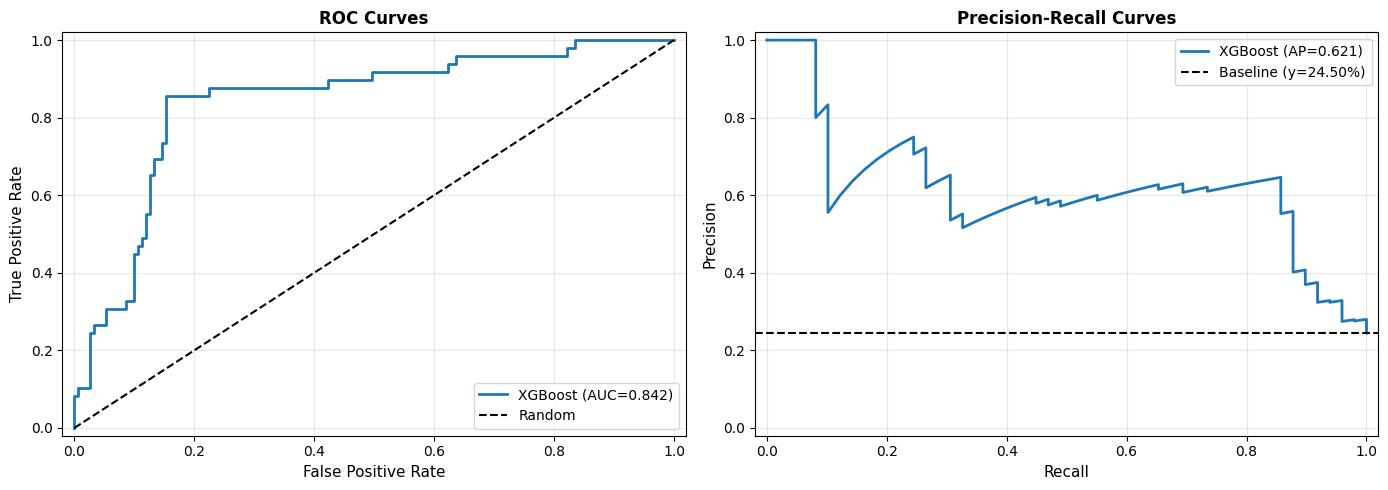

In [7]:
# Plot ROC/PR curves for the best model from each dataset

# Helper to find best model from simulation results (Optimized F2)
def get_best_from_sim(dataset_name, sim_results):
    ds_res = [r for r in sim_results if r['dataset'] == dataset_name]
    if not ds_res: return None
    return max(ds_res, key=lambda x: x['f2'])

best_original = get_best_from_sim('Original', all_simulation_results)
best_trees = get_best_from_sim('Trees', all_simulation_results)

if best_original:
    print(f"\nBest Original Model (Optimized): {best_original['model']} (F2: {best_original['f2']:.4f}, Th: {best_original['threshold']:.2f})")
if best_trees:
    print(f"Best Trees Model (Optimized): {best_trees['model']} (F2: {best_trees['f2']:.4f}, Th: {best_trees['threshold']:.2f})")

# Determine overall best for plotting
best_overall = max(all_simulation_results, key=lambda x: x['f2'])
best_dataset_name = best_overall['dataset']
best_model_name = best_overall['model']
best_model_obj = all_best_models[best_dataset_name][best_model_name]
X_test_best, y_test_best = test_sets[best_dataset_name]
X_train_best, y_train_best = train_sets[best_dataset_name]

print(f"
Plotting curves for overall best model: {best_model_name} on {best_dataset_name} dataset")
fig = plot_roc_pr_curves({best_model_name: best_model_obj}, X_test_best, y_test_best)
plt.show()


In [8]:
# Save the absolute best model
save_path = Path("../artifacts") / f"best_tree_model_{best_model_name.lower()}_{best_dataset_name.lower()}.joblib"
save_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model_obj, save_path)
print(f"\n✓ Saved best model to {save_path}")




✓ Saved best model to ../artifacts/best_tree_model_xgboost_trees.joblib


In [9]:
# ================================================

def get_feature_names_from_column_transformer(ct):
    """
    Extract ordered feature names from a fitted ColumnTransformer,
    handling scalers, OHE, passthrough, etc.
    """
    output_features = []

    for name, transformer, cols in ct.transformers_:
        if name == 'remainder' and transformer == 'drop':
            continue

        # 1. Transformers with get_feature_names_out
        if hasattr(transformer, "get_feature_names_out"):
            try:
                names = transformer.get_feature_names_out(cols)
            except:
                names = transformer.get_feature_names_out()
            output_features.extend(names)

        # 2. Transformers without get_feature_names_out (e.g., scalers)
        elif cols is not None:
            output_features.extend(cols)

    return output_features

# Use the best model identified in the previous cells
print(f"Plotting feature importance for: {best_model_name} on {best_dataset_name}")

best_pipe = best_model_obj
importances = None
prep = None

# Helper to get estimator from _CalibratedClassifier
def get_underlying_estimator(calib_clf):
    if hasattr(calib_clf, "estimator"):
        return calib_clf.estimator
    return calib_clf.base_estimator

# Logic to extract prep and importances based on model type
if hasattr(best_pipe, "calibrated_classifiers_"):
    # Case 1: CalibratedClassifierCV (wrapping a Pipeline)
    print("Model is CalibratedClassifierCV. Averaging importances across folds...")
    try:
        # Get preprocessor from the first fold's pipeline
        first_calib = best_pipe.calibrated_classifiers_[0]
        first_pipe = get_underlying_estimator(first_calib)
        prep = first_pipe.named_steps["prep"]
        
        # Average importances
        imps = []
        for calib in best_pipe.calibrated_classifiers_:
            pipe = get_underlying_estimator(calib)
            clf = pipe.named_steps["clf"]
            if hasattr(clf, "feature_importances_"):
                imps.append(clf.feature_importances_)
        
        if imps:
            importances = np.mean(imps, axis=0)
    except Exception as e:
        print(f"Could not extract importances from CalibratedClassifierCV: {e}")

elif hasattr(best_pipe, "named_steps"):
    # Case 2: Standard Pipeline
    prep = best_pipe.named_steps["prep"]
    clf = best_pipe.named_steps["clf"]
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_

elif hasattr(best_pipe, "estimators_"):
    # Case 3: VotingClassifier
    print("VotingClassifier: Feature importance plot not supported (ensemble of ensembles).")
    importances = None

else:
    print(f"Unknown model structure: {type(best_pipe)}")


if prep is not None and importances is not None:
    # Extract correct feature names
    feature_names = get_feature_names_from_column_transformer(prep)
    
    # Build DF and SORT DESCENDING
    df_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    # Plot
    plt.figure(figsize=(10, 8))
    # Explicitly pass 'order' to ensure the most important is at the top
    sns.barplot(
        data=df_imp.head(20), 
        x="importance", 
        y="feature", 
        palette="viridis",
        order=df_imp.head(20)['feature']
    )
    plt.title(f"Top 20 Features - {best_model_name} (Calibrated)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    
    print("Top 20 Features Table:")
    print(df_imp.head(20))
else:
    print(f"Model {best_model_name} does not expose feature_importances_ or is not supported for plotting.")


Feature names: 162
Importances: (162,)


,feature,importance
73,incident_severity_Major Damage,0.167783
74,incident_severity_Minor Damage,0.080532
10,total_claim_amount,0.054472
75,incident_severity_Total Loss,0.037225
70,collision_type_Missing,0.029847
0,months_as_customer,0.028604
3,policy_annual_premium,0.025051
11,collision_type_missing,0.020285
17,days_since_bind,0.020004
15,injury_share,0.018614


In [10]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

def threshold_table(model, X_test, y_test, top=20):
    """
    Prints threshold vs precision, recall, F1, and F2 WITHOUT visualization.
    """
    y_scores = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

    rows = []
    # Correct alignment: thresholds[i] corresponds to precision[i+1], recall[i+1]
    for i, t in enumerate(thresholds):
        p = precision[i+1]
        r = recall[i+1]
        f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0
        # F2 score: beta=2. F2 = (1+4) * (p*r) / (4*p + r)
        f2 = (5 * p * r / (4 * p + r)) if (4 * p + r) > 0 else 0
        rows.append((t, p, r, f1, f2))

    # Sort by F2 descending (since that's our target) or Recall
    rows_sorted = sorted(rows, key=lambda x: x[4], reverse=True)  # sort by F2

    print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1':>10} | {'F2':>10}")
    print("-" * 68)
    for row in rows_sorted[:top]:
        print(f"{row[0]:10.3f} | {row[1]:10.3f} | {row[2]:10.3f} | {row[3]:10.3f} | {row[4]:10.3f}")

    return rows_sorted

best_model = best_model_obj
rows = threshold_table(best_model, X_test_best, y_test_best, top=20)


 Threshold |  Precision |     Recall |         F1 |         F2
--------------------------------------------------------------------
     0.507 |      0.646 |      0.857 |      0.737 |      0.805
     0.441 |      0.636 |      0.857 |      0.730 |      0.802
     0.438 |      0.627 |      0.857 |      0.724 |      0.798
     0.434 |      0.618 |      0.857 |      0.718 |      0.795
     0.434 |      0.609 |      0.857 |      0.712 |      0.792
     0.423 |      0.600 |      0.857 |      0.706 |      0.789
     0.541 |      0.641 |      0.837 |      0.726 |      0.788
     0.377 |      0.558 |      0.878 |      0.683 |      0.788
     0.414 |      0.592 |      0.857 |      0.700 |      0.787
     0.374 |      0.551 |      0.878 |      0.677 |      0.785
     0.409 |      0.583 |      0.857 |      0.694 |      0.784
     0.369 |      0.544 |      0.878 |      0.672 |      0.782
     0.394 |      0.575 |      0.857 |      0.689 |      0.781
     0.369 |      0.537 |      0.878 |      0.667

In [11]:
def predict_with_threshold(model, X, threshold):
    probs = model.predict_proba(X)[:, 1]
    return (probs >= threshold).astype(int)

import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

def tune_threshold_cv(model, X_train, y_train, cv=5):
    """
    Computes best thresholds using Cross-Validation predictions to avoid leakage.
    """
    print("Generating CV predictions for threshold tuning...")
    # 1. Get predicted probabilities via CV
    y_scores = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

    # 2. Compute full PR curve
    precision, recall, thresholds = precision_recall_curve(y_train, y_scores)

    # Fix: Slice precision and recall to match thresholds length
    # The last element of precision/recall corresponds to no threshold (limit case)
    precision = precision[:-1]
    recall = recall[:-1]

    # Compute F1 for all thresholds
    f1_values = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    # Compute F2 for all thresholds
    f2_values = 5 * (precision * recall) / (4 * precision + recall + 1e-10)

    # -----------------------------
    # Best threshold for F2 (Primary Goal)
    # -----------------------------
    idx_f2 = np.argmax(f2_values)
    best_f2_threshold = thresholds[idx_f2]
    best_f2 = f2_values[idx_f2]
    
    # -----------------------------
    # Best threshold for F1
    # -----------------------------
    idx_f1 = np.argmax(f1_values)
    best_f1_threshold = thresholds[idx_f1]
    best_f1 = f1_values[idx_f1]

    # -----------------------------
    # Best Recall Threshold (Constraint: Recall >= 0.95)
    # -----------------------------
    target_recall = 0.95
    mask = recall >= target_recall
    if mask.sum() > 0:
        # Pick the one with best F1 among those with high recall
        best_idx = np.argmax(f1_values[mask])
        best_recall_threshold = thresholds[mask][best_idx]
        best_recall_val = recall[mask][best_idx]
    else:
        # Fallback if no threshold meets 0.95 recall
        best_recall_threshold = 0.0
        best_recall_val = 1.0

    # -----------------------------
    # Print results
    # -----------------------------
    print("=== BEST F2 THRESHOLD (CV) ===")
    print(f"Threshold: {best_f2_threshold:.3f}")
    print(f"F2 Score:  {best_f2:.3f}")
    print()

    print("=== BEST F1 THRESHOLD (CV) ===")
    print(f"Threshold: {best_f1_threshold:.3f}")
    print(f"F1 Score:  {best_f1:.3f}")
    print()
    
    print(f"=== HIGH RECALL THRESHOLD (Recall >= {target_recall}) ===")
    print(f"Threshold: {best_recall_threshold:.3f}")
    print(f"Recall:    {best_recall_val:.3f}")

    return {
        "best_f2_threshold": best_f2_threshold,
        "best_f1_threshold": best_f1_threshold,
        "best_recall_threshold": best_recall_threshold
    }


# -----------------------------
# NOW call the function using TRAIN set (CV) to avoid leakage
# -----------------------------
tuned = tune_threshold_cv(best_model_obj, X_train_best, y_train_best)


Generating CV predictions for threshold tuning...


/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [09:18:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [09:18:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [09:18:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/.venv/lib/python3.14

IndexError: boolean index did not match indexed array along axis 0; size of axis is 800 but size of corresponding boolean axis is 801

In [ ]:
def predict_with_threshold(model, X, threshold):
    probs = model.predict_proba(X)[:, 1]
    return (probs >= threshold).astype(int)

# Use the tuned F2 threshold
threshold_f2 = tuned["best_f2_threshold"]

y_pred_f2 = predict_with_threshold(best_model_obj, X_test_best, threshold_f2)

from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, f1_score
print(f"=== Classification Report (Best F2 Threshold {threshold_f2:.3f}) ===")
print(classification_report(y_test_best, y_pred_f2))
print("Confusion Matrix:")
print(confusion_matrix(y_test_best, y_pred_f2))

# Explicitly print F2 Score
f2_final = fbeta_score(y_test_best, y_pred_f2, beta=2)
print(f"\nTest Set F2 Score: {f2_final:.4f}")

# ==========================================
# Comparison: Best F1 Threshold
# ==========================================
threshold_f1 = tuned["best_f1_threshold"]

y_pred_f1 = predict_with_threshold(best_model_obj, X_test_best, threshold_f1)

print(f"\n=== Classification Report (Best F1 Threshold {threshold_f1:.3f}) ===")
print(classification_report(y_test_best, y_pred_f1))
print("Confusion Matrix:")
print(confusion_matrix(y_test_best, y_pred_f1))

# Explicitly print F1 and F2 for this threshold
f1_final_at_f1 = f1_score(y_test_best, y_pred_f1)
f2_final_at_f1 = fbeta_score(y_test_best, y_pred_f1, beta=2)
print(f"\nTest Set F1 Score: {f1_final_at_f1:.4f}")
print(f"Test Set F2 Score: {f2_final_at_f1:.4f}")


=== Classification Report (Best F1 Threshold 0.295) ===
              precision    recall  f1-score   support

           0       0.96      0.32      0.49       151
           1       0.32      0.96      0.47        49

    accuracy                           0.48       200
   macro avg       0.64      0.64      0.48       200
weighted avg       0.80      0.48      0.48       200

[[ 49 102]
 [  2  47]]


In [ ]:
threshold_recall = 0.101

y_pred_recall = predict_with_threshold(best_model_obj, X_test_best, threshold_recall)

print("=== Classification Report (Best Recall Threshold 0.101) ===")
print(classification_report(y_test_best, y_pred_recall))
print(confusion_matrix(y_test_best, y_pred_recall))


NameError: name 'predict_with_threshold' is not defined

In [ ]:
num_cols = [
    # all the numeric columns you used before
    'policy_premium', 'policy_deductible', 'total_claim_amount',
    'vehicle_claim', 'injury_claim', 'property_claim',
    'vehicle_value', 'annual_mileage', 'policy_age_days',
    'insured_age', 'incident_hour', 
    # and so on...
]
